In [1]:
# Cell 1 — Env vars, imports, device
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

In [2]:
# Cell 2 — Reload SoftPermutationMix and MultiOmicsNet definitions
# (paste Cell 4 and Cell 5 from notebook 03 here - already done)

# Cell 4 — Import SoftPermutationMix
# (copy-pasted here so this notebook is self-contained)

class SoftPermutationMix(nn.Module):
    def __init__(self, dim, K=4):
        super().__init__()
        self.dim = dim
        self.K = K
        self.alpha_logits = nn.Parameter(torch.zeros(K))
        perms = [torch.eye(dim)[torch.randperm(dim)] for _ in range(K)]
        self.register_buffer("perms", torch.stack(perms))

    def get_mixing_matrix(self):
        alpha = torch.softmax(self.alpha_logits, dim=0)
        return torch.einsum("k,kij->ij", alpha, self.perms)

    def forward(self, x):
        return x @ self.get_mixing_matrix().T

    def get_alpha(self):
        return torch.softmax(self.alpha_logits, dim=0).detach().cpu().numpy()

# Cell 5 — MultiOmicsNet architecture
# Each omics block gets its own encoder, then a joint representation is formed.
# When use_mix=True, a SoftPermutationMix layer routes cross-omics information.

class MultiOmicsNet(nn.Module):
    def __init__(
        self,
        n_mrna=200, n_mirna=50, n_methy=200, n_cnv=200,
        latent_dim=64, n_classes=5, use_mix=True, K=4
    ):
        super().__init__()
        self.use_mix = use_mix
        self.block_sizes = [n_mrna, n_mirna, n_methy, n_cnv]

        # Independent encoder per omics type
        self.encoders = nn.ModuleList([
            nn.Sequential(
                nn.Linear(s, latent_dim),
                nn.LayerNorm(latent_dim),
                nn.GELU(),
                nn.Dropout(0.2)
            )
            for s in self.block_sizes
        ])

        joint_dim = latent_dim * len(self.block_sizes)  # 64*4 = 256

        if use_mix:
            self.mixer = SoftPermutationMix(dim=joint_dim, K=K)

        # Final classification head
        self.head = nn.Sequential(
            nn.Linear(joint_dim, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        splits = torch.split(x, self.block_sizes, dim=-1)
        latents = [enc(s) for enc, s in zip(self.encoders, splits)]
        joint = torch.cat(latents, dim=-1)
        if self.use_mix:
            joint = self.mixer(joint)
        return self.head(joint)

In [4]:
# Cell 3 — Load trained model
model_mix = MultiOmicsNet(
    n_mrna=3217, n_mirna=383, n_methy=3139, n_cnv=3105,
    latent_dim=64, n_classes=32, use_mix=True, K=4
)
model_mix.load_state_dict(torch.load("model_mix.pt", map_location="cpu"))
model_mix.eval()
print("Model loaded.")

print("\nLearned permutation weights α:")
print(model_mix.mixer.get_alpha().round(4))

print("\nInterpretation guide:")
print("  Diagonal    → self-routing (an omics block mostly informs itself)")
print("  Off-diagonal → cross-omics routing (e.g. CNV informs mRNA representation)")
print("  High value  → strong learned dependency between those two modalities")

Model loaded.

Learned permutation weights α:
[0.2497 0.2464 0.2435 0.2604]

Interpretation guide:
  Diagonal    → self-routing (an omics block mostly informs itself)
  Off-diagonal → cross-omics routing (e.g. CNV informs mRNA representation)
  High value  → strong learned dependency between those two modalities


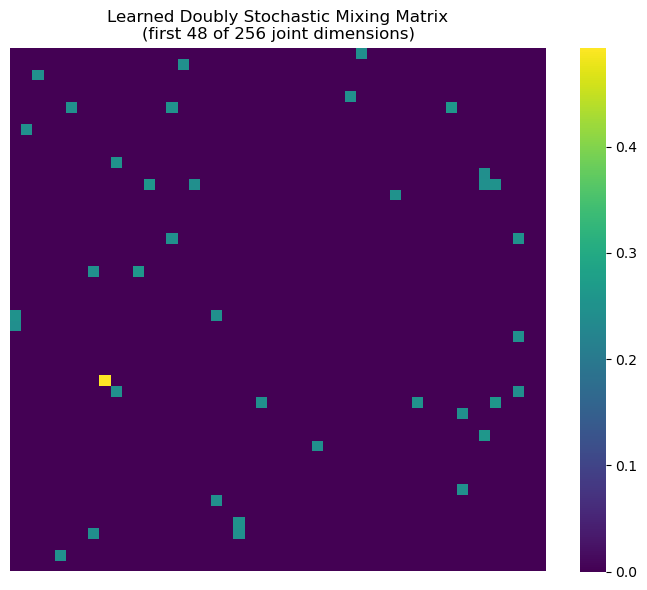

In [5]:
# Cell 4 — Full mixing matrix heatmap (first 48 dims for readability)
D = model_mix.mixer.get_mixing_matrix().detach().cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(D[:48, :48], cmap="viridis",
            xticklabels=False, yticklabels=False, ax=ax)
ax.set_title("Learned Doubly Stochastic Mixing Matrix\n(first 48 of 256 joint dimensions)", fontsize=12)
plt.tight_layout()
plt.savefig("04_mixing_matrix_full.png", dpi=150)
plt.show()

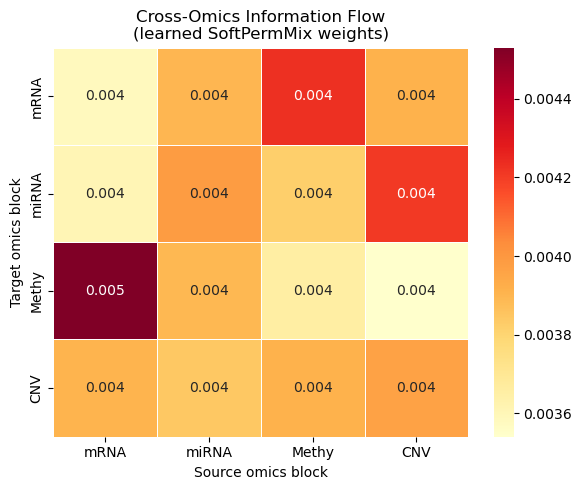


Interpretation guide:
  Diagonal    → self-routing (an omics block mostly informs itself)
  Off-diagonal → cross-omics routing (e.g. CNV informs mRNA representation)
  High value  → strong learned dependency between those two modalities


In [6]:
# Cell 5 — Cross-omics information flow heatmap
# This is the key biological interpretation cell:
# Which omics block routes most strongly into which other block?

block_names = ["mRNA", "miRNA", "Methy", "CNV"]
block_size = 64  # latent_dim per block
flow = np.zeros((4, 4))

for i in range(4):
    for j in range(4):
        src = slice(i * block_size, (i + 1) * block_size)
        tgt = slice(j * block_size, (j + 1) * block_size)
        flow[j, i] = D[tgt, src].mean()  # how much src flows into tgt

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    flow, annot=True, fmt=".3f",
    xticklabels=block_names, yticklabels=block_names,
    cmap="YlOrRd", linewidths=0.5, ax=ax
)
ax.set_title("Cross-Omics Information Flow\n(learned SoftPermMix weights)", fontsize=12)
ax.set_xlabel("Source omics block")
ax.set_ylabel("Target omics block")
plt.tight_layout()
plt.savefig("04_crossomics_flow.png", dpi=150)
plt.show()

print("\nInterpretation guide:")
print("  Diagonal    → self-routing (an omics block mostly informs itself)")
print("  Off-diagonal → cross-omics routing (e.g. CNV informs mRNA representation)")
print("  High value  → strong learned dependency between those two modalities")